Import the Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

url = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/number_of_demonstration_events_by_country-year_as-of-03Apr2026.csv'

url2 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/US-and-Canada_aggregated_data_up_to_week_of-2026-03-28.csv'

url3 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/Middle-East_aggregated_data_up_to_week_of-2026-03-21.csv'

url4 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/Latin-America-the-Caribbean_aggregated_data_up_to_week_of-2026-03-21.csv'

url5 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/Europe-Central-Asia_aggregated_data_up_to_week_of-2026-03-28.csv'

url6 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/Asia-Pacific_aggregated_data_up_to_week_of-2026-03-28.csv'

url7 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/Asia-Pacific_aggregated_data_up_to_week_of-2026-03-28%20(2).csv'

url8 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/Africa_aggregated_data_up_to_week_of-2026-03-21.csv'

url9 = 'https://raw.githubusercontent.com/QhungChang/POLI3148-Assignment-1/refs/heads/main/data/Africa_aggregated_data_up_to_week_of-2026-03-21%20(2).csv'


demo = pd.read_csv(url)
North_America = pd.read_csv(url2)
Middle_East = pd.read_csv(url3)
Latin_America = pd.read_csv(url4)
Europe_Central_Asia = pd.read_csv(url5)
Asia_Pacific = pd.read_csv(url6)
Asia_Pacific2 = pd.read_csv(url7)
Africa = pd.read_csv(url8)
Africa2 = pd.read_csv(url9)

Merge Data from Different Regions into one big dataset

In [2]:
all = pd.concat([
    North_America,
    Middle_East,
    Latin_America,
    Europe_Central_Asia,
    Asia_Pacific,
    Asia_Pacific2,
    Africa,
    Africa2
], ignore_index=True)

In [3]:
all['DATE'] = pd.to_datetime(all['WEEK'], errors='coerce')

In [4]:
all['YEAR'] = pd.to_datetime(all['WEEK'], errors='coerce').dt.year

In [5]:
demo1 = all[
    (all['YEAR'] >= 2021) &
    (all['SUB_EVENT_TYPE'].isin([
        'Peaceful protest',
        'Protest with intervention',
        'Excessive force against protesters',
        'Violent demonstration'
    ])) & (all['YEAR'] < 2026)
]

Data Analysis

<Axes: title={'center': 'Demonstration Events 2021-2025 (Globally)'}, xlabel='DATE'>

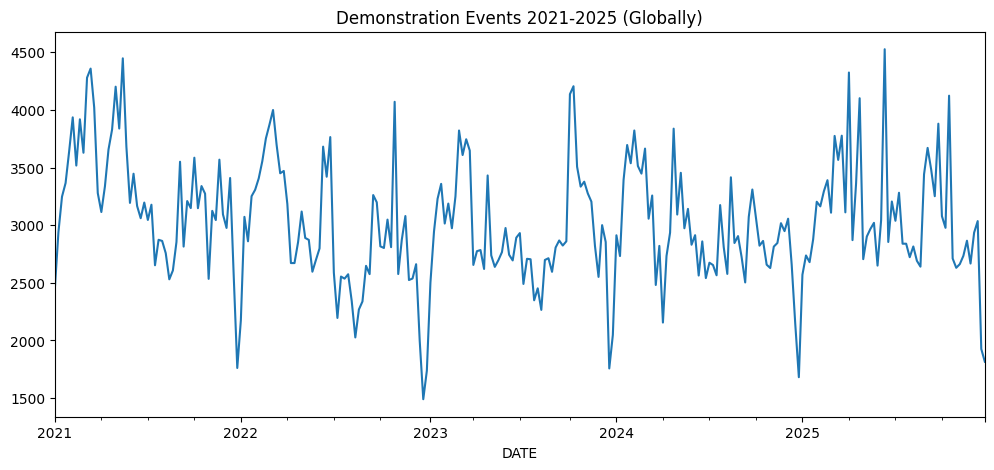

In [6]:
monthly_timeline_date = (
    demo1.groupby('DATE')['EVENTS']
    .sum()
    .sort_index()
)

monthly_timeline_date.plot(figsize=(12, 5), title='Demonstration Events 2021-2025 (Globally)')

In [7]:
demo1['YEAR'].value_counts().sort_index()

,count
YEAR,
2021,48741
2022,46540
2023,44564
2024,42966
2025,43775


In [8]:
demo1.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,DATE,YEAR
0,09-April-2022,North America,Bermuda,Devonshire,Protests,Peaceful protest,1,0,1882.0,Demonstrations,3888.0,32.3033,-64.7595,2022-04-09,2022
1,01-May-2021,North America,Bermuda,Pembroke,Protests,Peaceful protest,1,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896,2021-05-01,2021
2,26-June-2021,North America,Bermuda,Pembroke,Protests,Peaceful protest,1,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896,2021-06-26,2021
3,28-August-2021,North America,Bermuda,Pembroke,Protests,Peaceful protest,2,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896,2021-08-28,2021
4,06-November-2021,North America,Bermuda,Pembroke,Protests,Peaceful protest,1,0,2260.0,Demonstrations,3891.0,32.2991,-64.7896,2021-11-06,2021


COUNTRY
India            92177
United States    66409
France           37306
Pakistan         35444
Mexico           31829
South Korea      30591
Turkey           23259
Italy            21564
Germany          20788
Yemen            20139
Spain            19800
Iran             19153
Indonesia        15954
Myanmar          15356
Brazil           13558
Name: EVENTS, dtype: int64


<Axes: title={'center': 'Top 15 Countries by Demonstration Events'}, ylabel='COUNTRY'>

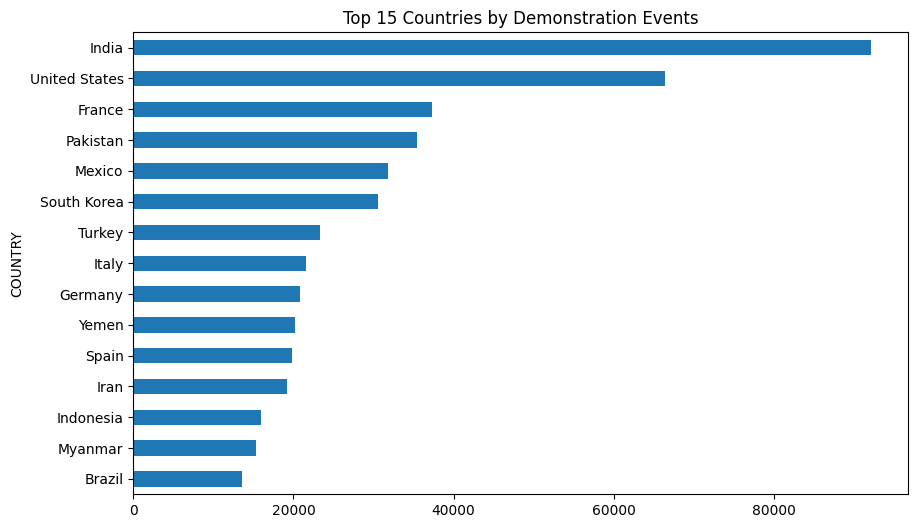

In [9]:
top_countries = (
    demo1.groupby('COUNTRY')['EVENTS']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print(top_countries)

top_countries.sort_values().plot(kind='barh', figsize=(10, 6), title='Top 15 Countries by Demonstration Events')

REGION
Europe                       174176
South Asia                   153291
North America                107199
Middle East                   98417
South America                 75254
East Asia                     51245
Southeast Asia                36263
Northern Africa               23251
Eastern Africa                13014
Caucasus and Central Asia     11203
Central America               10847
Western Africa                10407
Southern Africa                9316
Oceania                        6303
Caribbean                      5826
Middle Africa                  3721
Antarctica                        9
Name: EVENTS, dtype: int64


<Axes: title={'center': 'Demonstration Events by Region'}, ylabel='REGION'>

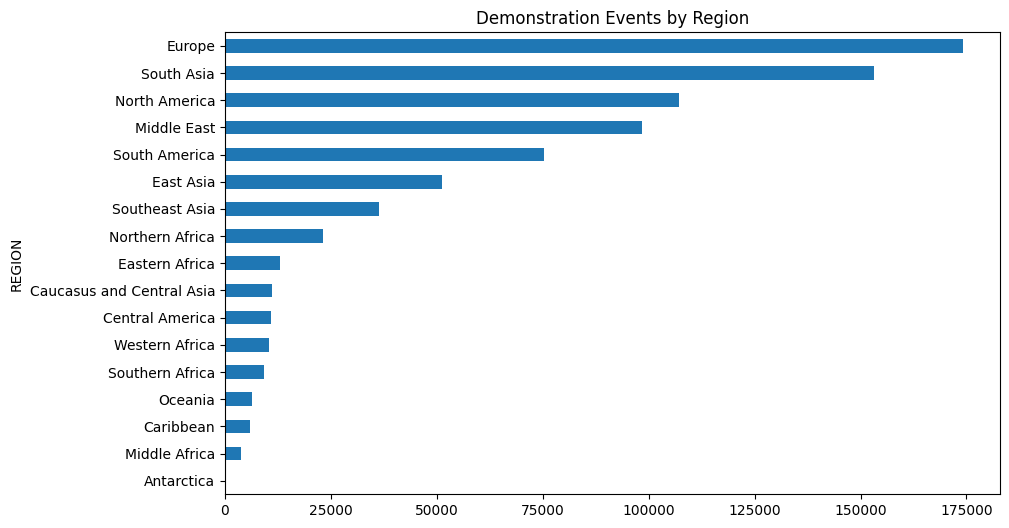

In [10]:
top_regions = (
    demo1.groupby('REGION')['EVENTS']
    .sum()
    .sort_values(ascending=False)
)

print(top_regions)

top_regions.sort_values().plot(kind='barh', figsize=(10, 6), title='Demonstration Events by Region')

COUNTRY
Bangladesh                      1481
Myanmar                          636
Iran                             530
Democratic Republic of Congo     264
Kenya                            236
Mozambique                       228
Kazakhstan                       200
Sudan                            183
Nigeria                          153
Angola                           147
Chad                             145
Somalia                          142
Pakistan                         129
Haiti                            118
Ethiopia                         114
Name: FATALITIES, dtype: int64


<Axes: title={'center': 'Top 15 Countries by Demonstration Fatalities'}, ylabel='COUNTRY'>

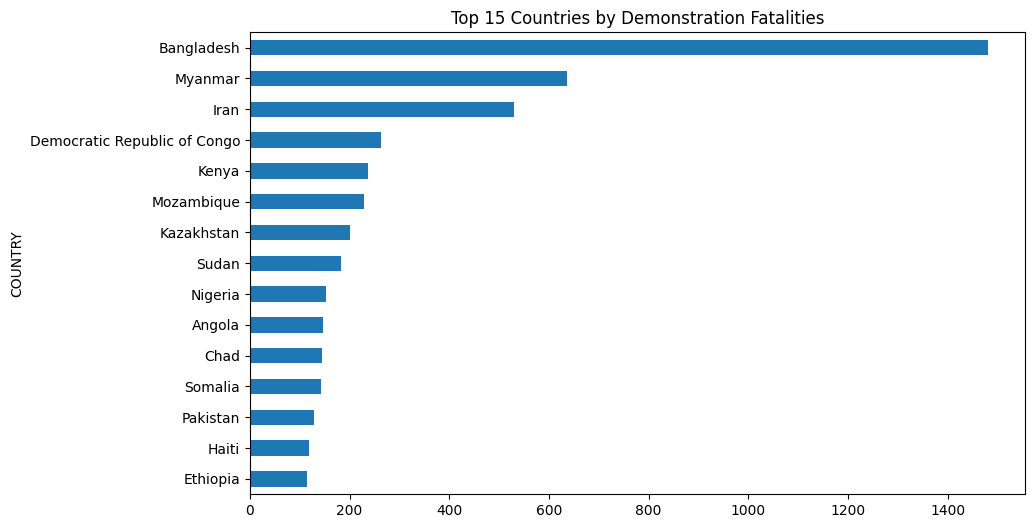

In [11]:
fatalities_by_country = (
    demo1.groupby('COUNTRY')['FATALITIES']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print(fatalities_by_country)

fatalities_by_country.sort_values().plot(kind='barh', figsize=(10, 6), title='Top 15 Countries by Demonstration Fatalities')

REGION
South Asia                   1776
Eastern Africa                845
Middle East                   748
Southeast Asia                667
Middle Africa                 647
Western Africa                397
Caucasus and Central Asia     283
South America                 246
Northern Africa               194
Southern Africa               130
Caribbean                     124
North America                  74
Oceania                        21
Europe                         11
Central America                 5
East Asia                       4
Antarctica                      0
Name: FATALITIES, dtype: int64


<Axes: title={'center': 'Demonstration Fatalities by Region'}, ylabel='REGION'>

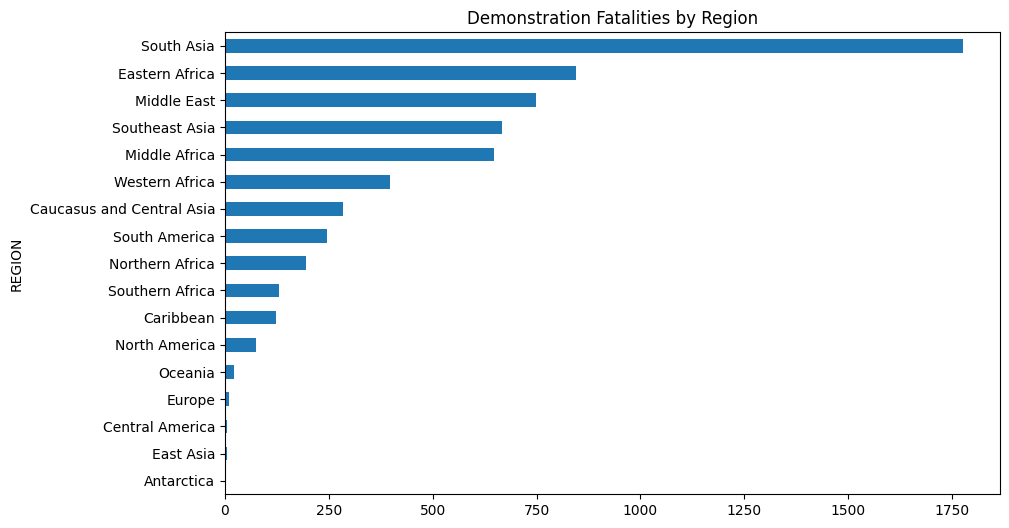

In [12]:
fatalities_by_region = (
    demo1.groupby('REGION')['FATALITIES']
    .sum()
    .sort_values(ascending=False)
)

print(fatalities_by_region)

fatalities_by_region.sort_values().plot(kind='barh', figsize=(10, 6), title='Demonstration Fatalities by Region')

                           total_events  total_fatalities  \
REGION                                                      
Middle Africa                      3721               647   
Eastern Africa                    13014               845   
Western Africa                    10407               397   
Caucasus and Central Asia         11203               283   
Caribbean                          5826               124   
Southeast Asia                    36263               667   
Southern Africa                    9316               130   
South Asia                       153291              1776   
Northern Africa                   23251               194   
Middle East                       98417               748   
Oceania                            6303                21   
South America                     75254               246   
North America                    107199                74   
Central America                   10847                 5   
East Asia               

<Axes: title={'center': 'Fatalities per Event by Region'}, ylabel='REGION'>

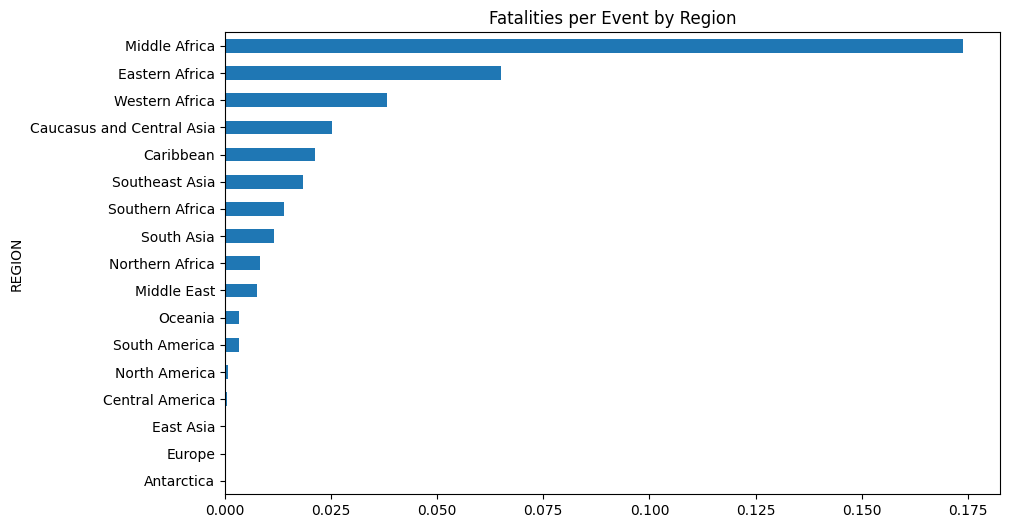

In [13]:
region_intensity = (
    demo1.groupby('REGION')
    .agg(total_events=('EVENTS', 'sum'),
         total_fatalities=('FATALITIES', 'sum'))
)

region_intensity['fatalities_per_event'] = (
    region_intensity['total_fatalities'] / region_intensity['total_events']
)

region_intensity = region_intensity.sort_values('fatalities_per_event', ascending=False)

print(region_intensity)

region_intensity['fatalities_per_event'].sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Fatalities per Event by Region'
)

In [14]:
intervention_demo = demo1[
    demo1['SUB_EVENT_TYPE'].isin([
        'Protest with intervention',
        'Excessive force against protesters'
    ])
].copy()

REGION
Middle Africa                0.166353
Eastern Africa               0.094821
Western Africa               0.080907
Northern Africa              0.059911
Caucasus and Central Asia    0.058377
Oceania                      0.056164
Caribbean                    0.050463
South Asia                   0.039891
Middle East                  0.038276
Southeast Asia               0.037862
Southern Africa              0.034994
Europe                       0.031996
North America                0.021278
Central America              0.018254
South America                0.016451
East Asia                    0.011260
Antarctica                   0.000000
Name: EVENTS, dtype: float64


<Axes: title={'center': 'Share of Demonstration Events with Intervention by Region'}, ylabel='REGION'>

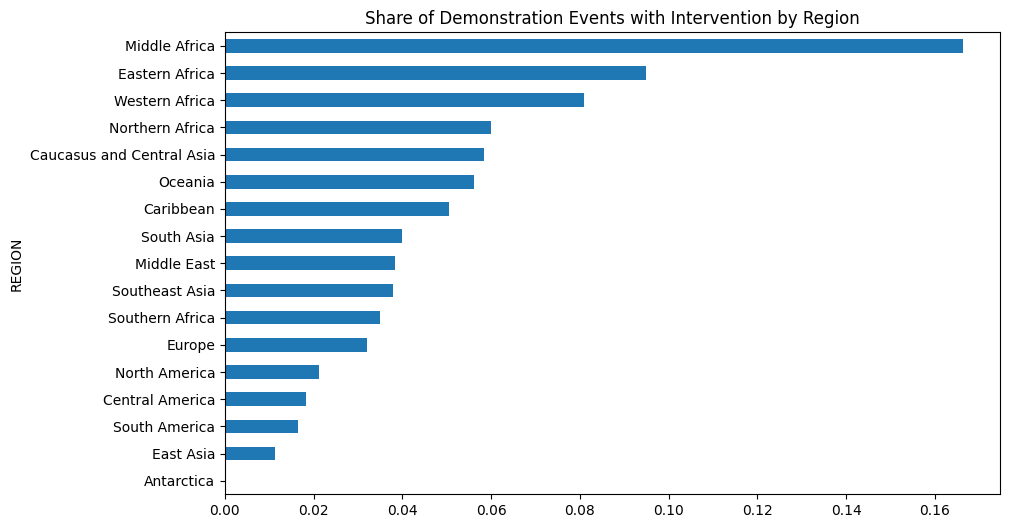

In [15]:
region_total = demo1.groupby('REGION')['EVENTS'].sum()
region_intervention = intervention_demo.groupby('REGION')['EVENTS'].sum()

intervention_share = (region_intervention / region_total).fillna(0).sort_values(ascending=False)

print(intervention_share)

intervention_share.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Share of Demonstration Events with Intervention by Region'
)

COUNTRY
Guinea-Bissau                   0.373333
Nicaragua                       0.297872
Sierra Leone                    0.260870
Chad                            0.245399
Angola                          0.236585
Gambia                          0.233333
Uganda                          0.229446
Russia                          0.224193
Maldives                        0.218650
Zimbabwe                        0.199029
Cuba                            0.198582
Sudan                           0.174095
Democratic Republic of Congo    0.171583
Fiji                            0.166667
Cambodia                        0.165333
Name: EVENTS, dtype: float64


<Axes: title={'center': 'Top Countries by Share of Demonstration Events with Intervention'}, ylabel='COUNTRY'>

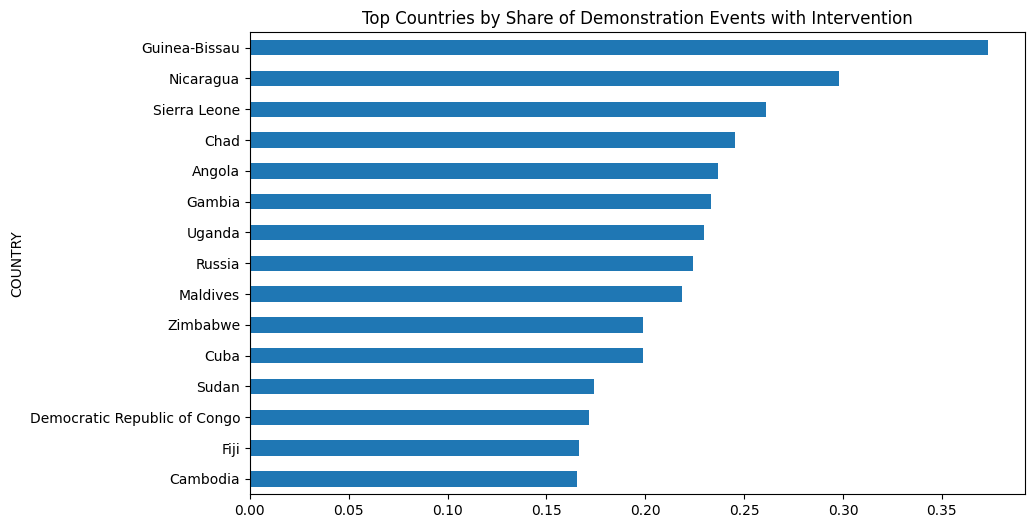

In [16]:

country_total = demo1.groupby('COUNTRY')['EVENTS'].sum()
country_intervention = intervention_demo.groupby('COUNTRY')['EVENTS'].sum()

country_intervention_share = (country_intervention / country_total).fillna(0)

# keep countries with at least 30 demonstration events
country_intervention_share = country_intervention_share[country_total >= 30]

country_intervention_share = country_intervention_share.sort_values(ascending=False).head(15)

print(country_intervention_share)

country_intervention_share.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top Countries by Share of Demonstration Events with Intervention'
)

SUB_EVENT_TYPE
Peaceful protest                      727521
Violent demonstration                  35383
Protest with intervention              24759
Excessive force against protesters      2079
Name: EVENTS, dtype: int64


<Axes: title={'center': 'Demonstration Sub-Event Types'}, ylabel='SUB_EVENT_TYPE'>

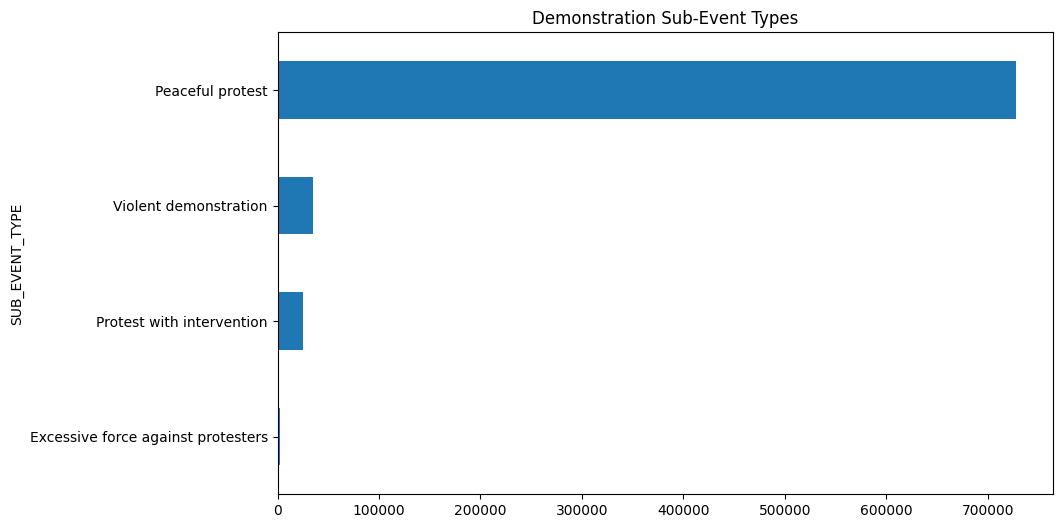

In [17]:
subevent_counts = (
    demo1.groupby('SUB_EVENT_TYPE')['EVENTS']
    .sum()
    .sort_values(ascending=False)
)

print(subevent_counts)

subevent_counts.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Demonstration Sub-Event Types'
)